In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph.message import add_messages

# 상태 정의
class State(TypedDict):	
    messages: Annotated[list[str], add_messages]

In [3]:
from langgraph.graph import StateGraph

# 그래프 구성
graph_builder = StateGraph(State)

In [ ]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """
    특정 지역의 현재 시각을 반환하는 함수.
    
    Args:
        timezone (str): pytz 타임존 형식의 문자열 (예: 'Asia/Seoul', 'America/New_York', 'Europe/London')
                       한국의 경우 'Asia/Seoul'을 사용합니다.
        location (str): 사용자가 질문한 도시나 지역 이름 (예: '서울', '부산', '뉴욕')
    
    Returns:
        str: 해당 지역의 현재 시각 정보
    
    Examples:
        - 부산의 현재 시각: timezone='Asia/Seoul', location='부산'
        - 서울의 현재 시각: timezone='Asia/Seoul', location='서울'
        - 뉴욕의 현재 시각: timezone='America/New_York', location='뉴욕'
    """
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

In [5]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "부산"})

'Asia/Seoul (부산) 현재시각 2025-12-05 22:10:55'

In [6]:
query = "2025년 쿠팡 개인정보 유출 사건의 원인은?"

In [7]:
tools[1].invoke({"query": query, "search_period": "m"})


-------- WEB SEARCH --------
2025년 쿠팡 개인정보 유출 사건의 원인은?
m
1. snippet: 30일 네이버에 쿠팡 개인정보유출 집단소송 카페가 잇따라 개설되고 있다. 일부 카페는 가입자 수가 하루 만에 1000명 이상 늘었다. 쿠팡 개인정보 유출 집단 소송 카페. /, title: ‘ 개인정보 유출 ’ 쿠팡 … 집단소송 카페도 우후죽순 - 조선비즈, link: https://biz.chosun.com/topics/topics_social/2025/11/30/JVJF56WHV5ABLP6IPHRJZVZAI4/
2. snippet: 이정화 2025. 11. 30.올해 1~2월에는 GS리테일에서 개인정보 유출 사고가 발생했다. GS25 홈페이지를 통해 약 9만여명의 개인정보가 유출된 것으로 파악됐고, 계열 홈쇼핑 웹사이트에서는 158만건의 추가 유출 정황이 확인됐다., title: 5개월 전부터 낯선 로그인… 쿠팡 '3370만명' 개인정보 유출, link: https://v.daum.net/v/20251130113428347
3. snippet: 2025 년 11월 29일 작성자: abcinfo. 결론. 쿠팡의 개인정보 유출 사건은 소비자들에게 큰 충격을 주었으며, 개인정보 보호의 중요성을 다시 한번 일깨워 주었습니다., title: 쿠팡 개인정보 유출 사건: 우리가 알아야 할 모든 것 - ABC인포, link: https://abcinfo.kr/쿠팡-개인정보-유출-사건-우리가-알아야-할-모든-것/
4. snippet: 쿠팡 개인정보 유출 사건의 배경과 문제점. 2025 년 11월, 쿠팡에서 발생한 개인정보 유출 사건은 단순한 해킹 사고를 넘어 국내 전자상거래 업계에 큰 충격을 주었습니다., title: 쿠팡 집단 소송 개인정보 유출 소비자 대응 | CALL ME, link: https://call.oreurak.kr/쿠팡-집단-소송-개인정보-유출-소비자-대응/


"snippet: 30일 네이버에 쿠팡 개인정보유출 집단소송 카페가 잇따라 개설되고 있다. 일부 카페는 가입자 수가 하루 만에 1000명 이상 늘었다. 쿠팡 개인정보 유출 집단 소송 카페. /, title: ‘ 개인정보 유출 ’ 쿠팡 … 집단소송 카페도 우후죽순 - 조선비즈, link: https://biz.chosun.com/topics/topics_social/2025/11/30/JVJF56WHV5ABLP6IPHRJZVZAI4/;\nsnippet: 이정화 2025. 11. 30.올해 1~2월에는 GS리테일에서 개인정보 유출 사고가 발생했다. GS25 홈페이지를 통해 약 9만여명의 개인정보가 유출된 것으로 파악됐고, 계열 홈쇼핑 웹사이트에서는 158만건의 추가 유출 정황이 확인됐다., title: 5개월 전부터 낯선 로그인… 쿠팡 '3370만명' 개인정보 유출, link: https://v.daum.net/v/20251130113428347;\nsnippet: 2025 년 11월 29일 작성자: abcinfo. 결론. 쿠팡의 개인정보 유출 사건은 소비자들에게 큰 충격을 주었으며, 개인정보 보호의 중요성을 다시 한번 일깨워 주었습니다., title: 쿠팡 개인정보 유출 사건: 우리가 알아야 할 모든 것 - ABC인포, link: https://abcinfo.kr/쿠팡-개인정보-유출-사건-우리가-알아야-할-모든-것/;\nsnippet: 쿠팡 개인정보 유출 사건의 배경과 문제점. 2025 년 11월, 쿠팡에서 발생한 개인정보 유출 사건은 단순한 해킹 사고를 넘어 국내 전자상거래 업계에 큰 충격을 주었습니다., title: 쿠팡 집단 소송 개인정보 유출 소비자 대응 | CALL ME, link: https://call.oreurak.kr/쿠팡-집단-소송-개인정보-유출-소비자-대응/"

In [8]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x107d72480>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x107d72c00>


In [9]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [10]:
tools

[StructuredTool(name='get_current_time', description='현재 시각을 반환하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x107d72480>),
 StructuredTool(name='get_web_search', description='웹 검색을 수행하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_web_search'>, func=<function get_web_search at 0x107d72c00>)]

In [11]:
from pprint import pprint

# * 딕셔너리 컴프리헨션(Dictionary Comprehension)
# - 키(Key): tool.name은 현재 순회 중인 StructuredTool 객체의 name 속성 값을 추출하여 딕셔너리의 키로 사용한다.
# - 값(Value): tool은 현재 순회 중인 StructuredTool 객체 자체를 딕셔너리의 값으로 사용한다.
pprint({tool.name: tool for tool in tools})

{'get_current_time': StructuredTool(name='get_current_time', description='현재 시각을 반환하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x107d72480>),
 'get_web_search': StructuredTool(name='get_web_search', description='웹 검색을 수행하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_web_search'>, func=<function get_web_search at 0x107d72c00>)}


In [12]:
# * 왈러스(walrus) 연산자
# - 바다코끼리 닮아서 붙여진 이름
# - Python 3.8부터 도입된 문법
# - 일반적인 할당 연산자 (=)가 문(statement)인 반면, 왈러스 연산자는 식(expression)
# - 변수에 값을 할당하면서 동시에 그 값에 대한 참/거짓을 판별
dic = {"messages": ["a", "b"]}
if var := dic.get("messages"):
    print(var)

['a', 'b']


In [13]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    """

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools} # 딕셔너리 컴프리헨션(Dictionary Comprehension)

    def __call__(self, inputs: dict):
        # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
        if messages := inputs.get("messages", []): # 왈러스(walrus) 연산자 사용
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

In [14]:
# * Case1
tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [ ]:
# * Case2
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [16]:
from langgraph.graph import START, END

def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 END로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
        
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [17]:
graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")

In [18]:
graph = graph_builder.compile()

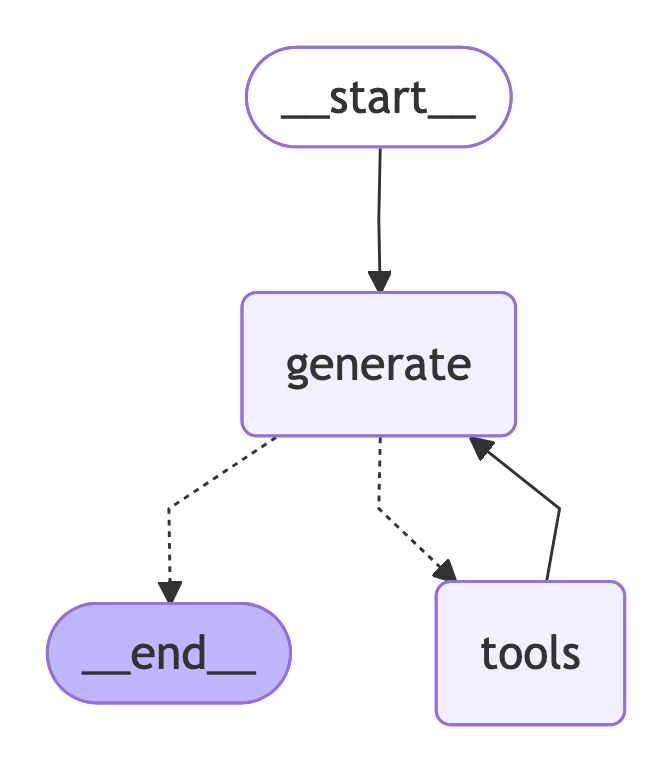

In [19]:
# [venv 경로]\Lib\site-packages\langchain_core\runnables\graph_mermaid.py
# 파일을 열고 `_render_mermaid_using_pyppeteer` 함수 내부에 있는 `pyppeteer.launch()` 호출 부분을 찾아 `executablePath` 인자를 추가한다.
# browser = await launch(executablePath=r'C:\Program Files\Google\Chrome\Application\chrome.exe')
import nest_asyncio
from IPython.display import display, Image
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# nest_asyncio를 적용하여 이벤트 루프 중첩 오류를 해결한다.
nest_asyncio.apply()

# (옵션) 그래프를 시각화
# 이 코드는 이미 langchain_core 라이브러리의 pyppeteer.launch()에 
# executablePath가 하드코딩된 상태를 전제로 한다.
display(Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

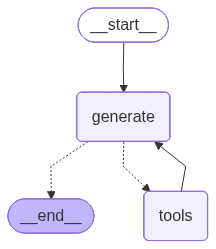

In [20]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [21]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 부산 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

부산은 2025년 12월 05일 22시 15분 22초 입니다.

In [22]:
gathered

AIMessageChunk(content='부산은 2025년 12월 05일 22시 15분 22초 입니다.', additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"timezone": "Asia/Seoul", "location": "\\ubd80\\uc0b0"}'}, '__gemini_function_call_thought_signatures__': {'3271e903-9fad-4226-9a3f-4218b11975fc': 'CiMBcsjafD5HnTCJgWX/ofKF8DRKp6g1Q3pIAgQsTxYpOEAqAQpkAXLI2nxoUuLNPDDE1/CUKnZxP9ErdQyKuP7Pr/ekqGIy7/e6oAA/35k65W2/vjnDwHfKiBLT2ouaqTTptPb/D+3YRHKLyuphJPD1tcifnaDzH71EE9odmldf4Xw3S+72Si+5JwrsAQFyyNp83Ox5K/jzKdRog29O+6fvyxSZohtodFNK9x+cx1wC8EQqrIyi2MXY3MDCndNCTv62kDvXi34963D/f9R8tANp2F8+yG4I2GqnLU+4vin/gMqMqAlrBnPSSiAJiJGmjLl1xitmwswv0cVoaULWcUe9Zsl3pvrRvHjohTV8ZKAnkdK2vX0/5JeAIb5xRD+38PDY5cqSPeATggKWz8yGy2WCt/PjMU0mf1e71D54TR63y/5M9Lf+77gv2x9f2mkEBcmlXvH8fLs/miX/wplQzDCAhIq1TY9SvXS3a6rCAY72EGsxxUjgEzraCtIBAXLI2nzpNZkEh5PUydR7ayWfITxkp1G5ULdIfvDc6dElldxaBLnbZTVeD44EGPbdPnrA+5R/y1HhMGWxHGbAfXypR9MYscHMLN8h6XFE8vnhlJJodNV7M++dvXw+yLa2op1aSLog87WgFqiH1A2w98/iqhAOF9j0XEfBOLe35VCTWLNWHisLBiPLDjJukoBUVXSNWNMyxb1

In [23]:
from langchain_core.messages import AIMessageChunk, SystemMessage

inputs = [
    SystemMessage(content=f"""
        너는 신문기자이다. 
        최근 {query}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.
    """),
    HumanMessage(content="""
        - 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
        - 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
        - 검색할 리스트를 토대로 재검색을 한다. 
        - 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
        - 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 
        
        더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
        제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
    """)
]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        # print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg


-------- WEB SEARCH --------
2025 쿠팡 개인정보 유출
m
1. snippet: 6 days ago · 쿠 팡 은 해외 서버를 통해 지난 6월 24일부터 무단으로 개인정보 에 접근한 것으로 추정하고 있다고 밝혔다. 쿠 팡 은 “결제 정보, 신용카드 번호, 로그인 정보는 노출되지 않았으므로 쿠 팡 이용 고객은 계정 관련 조치를 취할 필요가 없다”고 설명했다., title: 쿠팡, 개인정보 3370만개 유출... 이름·주소·전화번호 털렸다, link: https://www.chosun.com/economy/industry-company/2025/11/29/JHN2ES4R6BCDBEQX7VFC5EOOT4/
2. snippet: 2 days ago · 2025 년 11월 쿠팡 회원들을 대상으로 중국인으로 추정되는 내부자에 의해 발생한 개인 정보 유출 사태. 약 3,370만 개에 달하는 회원의 성명, 주소, 연락처 등이 대량으로 유출된 것으로 확인되었다., title: 쿠팡 개인정보 유출 사건 - 나무위키, link: https://namu.wiki/w/쿠팡+개인정보+유출+사건
3. snippet: Nov 21, 2025 · (서울=연합뉴스) 박형빈 기자 = 쿠 팡 이 고객 4천500여명의 개인정보 가 유출 된 침해사고가 발생하고도 열흘 넘게 이를 알아채지 못한 것으로 드러났다., title: '4천500명 개인정보 유출' 쿠팡, 털리고도 12일간 몰랐다 | 연합뉴스, link: https://www.yna.co.kr/view/AKR20251121138400017
4. snippet: 6 days ago · 2025 년 11월 쿠 팡 개인정보 3,370만개 유출 사고! 역대 최대 규모 해킹 사건의 전말·유출된 정보 (이름·주소·전화번호)·쿠팡 대응·고객 보호조치·손해배상 청구방법·보이스피싱 예방법까지 총정리., title: 쿠팡 개인정보 3370만개 유출 사건 총정리 | 유출범위·대처방안·손해..., link: https://www.wellb

In [30]:
gathered

AIMessageChunk(content=['', {'type': 'text', 'text': "## 2025 쿠팡 개인정보 유출, '국민 절반' 데이터 털렸다: 무엇이 문제였나\n\n**3,370만 명 정보 유출, 5개월 늑장 대응…", 'extras': {'signature': 'CiQBcsjafNDgxdBNqhNLoj/oE9zW3hKAZlc9I5eOh9QTLbNfWlsKdwFyyNp8lBe6Osy/OJf/3PX6Oqz+sr2C8BcDyg3VBaea6LCj+10GyoJXlHXPHp2kZ3i5dhW3NJeXxvRH+TOTP7XvVxHAqht02PK75Tjnq6qlPn9tL4k/kIpE3xOoCV9J0DRwYF7PnoHirG1O+Evlewj9QMN4pcN6Cp0CAXLI2nwyNrAlh51OSA/fMLx2CF/9/QWWujfY7mWMlQQND2akeQLDoYl11hlnYaH+I50aanMckHD7jQdTQV66BgARAK6o9c6vROm7DdM4bF9P1QDBrEtHpEup6768jzVtSWWvCliTqx1SZr4GEaDGLf8T4dDM2div8nH9ZcpgXrKWo1+rsZ24oNuEPxmwNOwbIujyB37nEDEx3GrEQokHr1//pddHxi7DrWAiZOwwxjPfLKGbwXKryxUMpdzNP8/URvdF0cUn03ad6w1sdo6ifTUPH1nVadqRdTc4bI/ITAteTm6SnVTuodQaw4rDwfeZt3EDV2/88ZpsyPQYJA8IT9fVbSYPzezj2OZ0fIuviCAKa7hp/EBAvxsEYh5/CskBAXLI2ny3Rh6mgX5/H5patByUQ019PxzwX1Hn3A0djw+LKfRB0FNfnf6U1Y9Dc01zDng6vohSe5CIXsYYHFJkfyhhseS0jv+VAA+nB9Tr3xEdVP+e8TdGEvYQ20LmZ4DBpPE2e8Rj8E8l09GZUUtzOT4t0oA1z+//4Fr+OMWYZ3X0W7Z5YkZ2i89pHuDWlRyumE9o9JXs6GZD2jPEG7e5vSU+X6vEUN8F3wQwMk6nRvDpufPKd

In [31]:
print(gathered.content[2])

'보안 불감증' 넘어선 '기업의 무책임' 도마 위**

2025년 11월, 대한민국 최대 이커머스 플랫폼 쿠팡에서 전 국민의 절반에 육박하는 3,370만 명의 개인정보가 유출되는 초유의 사태가 발생했다. 이름, 주소, 전화번호 등 민감한 개인 식별 정보가 대거 유출되면서 소비자들은 잠재적인 2차 피해의 공포에 떨고 있으며, 쿠팡의 안일한 보안 인식과 5개월에 걸친 '늑장 대응'은 거센 비판의 도마 위에 올랐다. 이번 사태는 단순한 해킹 사건을 넘어, 기업의 개인정보 관리 책임과 국가의 개인정보 보호 시스템 전반에 대한 근본적인 질문을 던지고 있다.

### 1. 사건의 전말과 충격적 규모: 3,370만 명의 개인정보가 털리다

쿠팡 개인정보 유출 사건은 지난 2025년 6월 24일경 해외 서버를 통한 무단 접근으로 시작된 것으로 추정된다. 그러나 쿠팡은 이 심각한 보안 침해를 무려 5개월이 지난 11월에야 공식적으로 인지하고 발표했다. 유출된 정보는 고객의 이름, 주소, 전화번호로, 결제 정보나 로그인 정보는 유출되지 않았다고 쿠팡 측은 설명했다. 하지만 3,370만 명이라는 숫자는 대한민국 전체 인구의 상당수를 차지하는 규모로, 사실상 '국민 절반'의 개인정보가 유출된 것과 다름없어 그 충격은 가늠하기 어렵다. 이는 국내에서 발생한 개인정보 유출 사건 중 역대급 규모로 기록될 전망이며, 대량의 민감 정보가 장기간 노출되었다는 점에서 심각성을 더한다.

### 2. '내부자 소행'에 뚫린 보안망: 5개월간의 치명적 공백

이번 유출 사건의 핵심 원인으로는 '내부자 소행' 가능성이 강력하게 제기되고 있다. 경찰 수사 결과, 쿠팡에 근무했던 중국 국적의 내부자에 의해 해외 서버를 통해 정보가 유출된 정황이 포착되었다. 이는 단순 외부 해킹을 넘어선 내부 시스템 접근 및 권한 관리의 총체적 부실을 시사한다. 어떻게 내부자가 5개월이라는 긴 시간 동안 대량의 개인정보에 무단으로 접근하고 이를 유출할 수 있었는지에 대한 의문이 증폭되고 있다. 쿠팡의 보안 시스템이 외부